In [1]:
import earthaccess
import ipywidgets as widgets
from ipywidgets import GridspecLayout

from itables import show

import xarray as xr
import numpy as np

In [2]:
# f@#$QFac890fq#@
earthaccess.login(persist=True)

Search for TEMPO collections

In [3]:
tempo_collections = earthaccess.search_datasets(
    project="TEMPO",
    keyword="NO2",
)

Summarize all the TEMPO collections Earthdata has

In [4]:
tempo_collections.summary(show_links=True)

Grab the NO2 measurements

In [5]:
no2_collection = tempo_collections[0]

In [6]:
# Search for all granules associated with this collection (this will take about a minute)
no2_granules = earthaccess.search_data(
    concept_id=no2_collection.concept_id()
)

KeyboardInterrupt: 

In [14]:
houston_coords = [29.751967740484655, -95.37026665444064]

houston_no2_granules = no2_granules.filter_spatial_extents(houston_coords, 'within')

In [36]:
houston_no2_granules[0].data_links()

['https://data.asdc.earthdata.nasa.gov/asdc-prod-protected/TEMPO/TEMPO_NO2_L2_V03/2023.08.02/TEMPO_NO2_L2_V03_20230802T154354Z_S001G06.nc']

In [ ]:
houston_no2_granules = earthaccess.open(houston_no2_granules[:10])

QUEUEING TASKS | :   0%|          | 0/5791 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/5791 [00:00<?, ?it/s]

In [16]:
no2_granule_xr = xr.open_mfdataset(houston_no2_granules, combine='by_coords')

In [17]:
no2_granule_xr

<xarray.Dataset> Size: 9kB
Dimensions:      (xtrack: 2048, mirror_step: 123)
Coordinates:
  * xtrack       (xtrack) int32 8kB 0 1 2 3 4 5 ... 2043 2044 2045 2046 2047
  * mirror_step  (mirror_step) int32 492B 615 616 617 618 ... 734 735 736 737
Data variables:
    *empty*
Attributes: (12/38)
    tio_commit:                       8e296545e1ee008557fb271292080e9584800967
    product_type:                     NO2
    processing_level:                 2
    processing_version:               3
    sdpc_version:                     TEMPO_SDPC_v4.4.0
    scan_num:                         1
    ...                               ...
    collection_shortname:             TEMPO_NO2_L2
    collection_version:               1
    keywords:                         EARTH SCIENCE>ATMOSPHERE>AIR QUALITY>NI...
    summary:                          Nitrogen dioxide Level 2 files provide ...
    coremetadata:                     \nGROUP                  = INVENTORYMET...
    history:                          2024-06-03T15:59:57Z:/tempo/nas0/sdpc_s...

In [22]:
no2_granule_xr.values

<bound method Mapping.values of <xarray.Dataset> Size: 9kB
Dimensions:      (xtrack: 2048, mirror_step: 123)
Coordinates:
  * xtrack       (xtrack) int32 8kB 0 1 2 3 4 5 ... 2043 2044 2045 2046 2047
  * mirror_step  (mirror_step) int32 492B 615 616 617 618 ... 734 735 736 737
Data variables:
    *empty*
Attributes: (12/38)
    tio_commit:                       8e296545e1ee008557fb271292080e9584800967
    product_type:                     NO2
    processing_level:                 2
    processing_version:               3
    sdpc_version:                     TEMPO_SDPC_v4.4.0
    scan_num:                         1
    ...                               ...
    collection_shortname:             TEMPO_NO2_L2
    collection_version:               1
    keywords:                         EARTH SCIENCE>ATMOSPHERE>AIR QUALITY>NI...
    summary:                          Nitrogen dioxide Level 2 files provide ...
    coremetadata:                     \nGROUP                  = INVENTORYMET...
  

In [15]:
no2_granule_xr.xtrack.dims

('xtrack',)

In [16]:
no2_granule_xr.xtrack.coords

Coordinates:
  * xtrack   (xtrack) int32 8kB 0 1 2 3 4 5 6 ... 2042 2043 2044 2045 2046 2047

In [26]:
no2_granule_xr.attrs['summary']

'Nitrogen dioxide Level 2 files provide trace gas information at TEMPO’s native spatial resolution, ~10 km^2 at the center of the Field of Regard (FOR), for individual granules. Each granule covers the entire North-South TEMPO FOR but only a portion of the East-West FOR. The files are provided in netCDF4 format, and contain information on tropospheric, stratospheric and total nitrogen dioxide vertical columns, ancillary data used in air mass factor and stratospheric/tropospheric separation calculations, and retrieval quality flags. The retrieval uses a three-step approach: (1) spectral fitting of slant columns, (2) air mass factor calculation and derivation of vertical columns, and (3) stratospheric/tropospheric separation. For further details, please refer to the ATBD.'

# Spatial filtering

In [72]:
from ipyleaflet import Map, GeomanDrawControl
from ipywidgets import Output

def get_spatial_boundary():
    m = Map(center=[42, -90], zoom=3)
    
    # Create a DrawControl for drawing on the map
    draw_control = GeomanDrawControl()
    
    # Configure the DrawControl to only allow points and rectangles
    draw_control.polyline = {}
    draw_control.polygon = {}
    draw_control.circlemarker = {}
    
    draw_control.rectangle = {
        "shapeOptions": {
            "fillColor": "#fca45d",
            "color": "#fca45d",
            "fillOpacity": 0.5
        }
    }
    draw_control.marker = {
        "shapeOptions": {
            "fillColor": "#fca45d",
            "color": "#fca45d",
            "fillOpacity": 1
        },
        "draggable": True
    }
    
    print(draw_control)

    # Add the DrawControl to the map
    m.add_control(draw_control)

    # Create an output widget to display results
    out = Output()

    # Define callback function for draw events
    def handle_draw(self, action, geo_json):
        print(action)
        print(geo_json)
        with out:
            out.clear_output()
            if action == 'create':
                if geo_json['geometry']['type'] == 'Point':
                    lat, lon = geo_json['geometry']['coordinates'][::-1]
                    print(f"[{lon}, {lat}]")
                    return (lat, lon)
                elif geo_json['geometry']['type'] == 'Polygon':  # Rectangle is a type of Polygon
                    coords = geo_json['geometry']['coordinates'][0]
                    min_lon, min_lat = min(coords[0][0], coords[2][0]), min(coords[0][1], coords[2][1])
                    max_lon, max_lat = max(coords[0][0], coords[2][0]), max(coords[0][1], coords[2][1])
                    print(f"[[{min_lon}, {min_lat}], [{max_lon}, {max_lat}]]")
                    return ((max_lat, min_lon), (min_lat, max_lon))
            elif action == 'edited':
                if geo_json['geometry']['type'] == 'Point':
                    lat, lon = geo_json['geometry']['coordinates'][::-1]
                    print(f"[{lon}, {lat}]")
                    return (lat, lon)

    # Attach the callback to the DrawControl
    draw_control.on_draw(handle_draw)

    # Display the map and output widget
    display(m, out)

GeomanDrawControl(marker={'shapeOptions': {'fillColor': '#fca45d', 'color': '#fca45d', 'fillOpacity': 1}, 'draggable': True}, options=['position'], rectangle={'shapeOptions': {'fillColor': '#fca45d', 'color': '#fca45d', 'fillOpacity': 0.5}})


Map(center=[42, -90], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_te…

Output()

create
[{'type': 'Feature', 'properties': {'style': {'draggable': True, 'icon': {'options': {'tooltipAnchor': [0, 0], 'iconUrl': '', 'iconRetinaUrl': '', 'iconSize': [25, 41], 'iconAnchor': [12, 41], 'shadowUrl': '', 'shadowSize': [41, 41], 'shadowAnchor': [12, 41], 'popupAnchor': [1, -34]}, '_initHooksCalled': True, '_needsInit': False}, 'rotationOrigin': '12px 41px', 'rotationAngle': 0, 'pane': 'markerPane'}, 'type': 'marker'}, 'geometry': {'type': 'Point', 'coordinates': [-109.335938, 38.68551]}}]

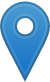
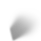

In [73]:
get_spatial_boundary()